In [1]:
!pip install tensorflow

# Step 1: Understanding Neural Network Basics

In [3]:
# x1w1 = 0.4 + b = 0.5
# x1w2 = 0.33 + b = 0.9

# activation function:

# relu
# sigmoid

# Step 2: Import Dataset

In [4]:
from tensorflow.keras.datasets import mnist


# MNIST is a built-in TensorFlow dataset.

# Step 3: Load Dataset

In [5]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Step 4: Check Dataset Shape

In [6]:
x_train.shape

(60000, 28, 28)

In [7]:
y_train.shape

(60000,)

In [8]:
x_test.shape

(10000, 28, 28)

In [10]:
y_test.shape

(10000,)

# Step 5: Visualize Images

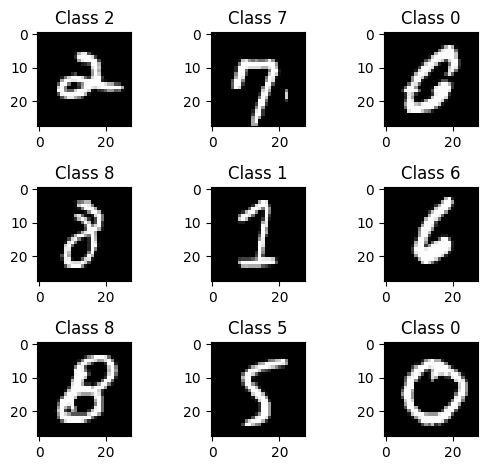

In [19]:
import random
import matplotlib.pyplot as plt

for i in range(9):
  plt.subplot(3,3, i+1)
  num = random.randint(0, len(x_train)-1)
  plt.imshow(x_train[num], cmap = 'gray')
  plt.title("Class {}".format(y_train[num]))

  plt.tight_layout()

In [21]:
# Better Version of the Code




# import random
# import matplotlib.pyplot as plt

# plt.figure(figsize=(8,8))

# for i in range(9):
#     plt.subplot(3,3,i+1)

#     num = random.randint(0, len(x_train)-1)

#     plt.imshow(x_train[num], cmap='gray')
#     plt.title(f"Class {y_train[num]}")
#     plt.axis('off')

# plt.tight_layout()
# plt.show()

# Step 6: Flatten Images

In [23]:
x_train = x_train.reshape(60000, 784)

x_test = x_test.reshape(10000, 784)

# Step 7: Normalize Data

In [24]:
x_train = x_train / 255
x_test = x_test / 255

# Step 8: One-Hot Encoding

In [26]:
import tensorflow.keras as keras

num_categories = 10

y_train = keras.utils.to_categorical(y_train, num_categories)
y_test = keras.utils.to_categorical(y_test, num_categories)

# Step 9: Create Neural Network

In [27]:
from tensorflow.keras.models import Sequential

model = Sequential()

# Step 10: Input Layer

In [30]:
from tensorflow.keras.layers import Dense

model.add(Dense(
    units = 32,
    activation = 'relu',
    input_shape = (784,)
    ))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Step 11: Hidden Layer

In [31]:
model.add(Dense(
    units = 512,
    activation = 'relu'
))

# Step 12: Output Layer

In [32]:
model.add(Dense(
    units = 10,
    activation = 'softmax'
))

# Step 13: Model Summary

In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,146 (184.16 KB)

 Trainable params: 47,146 (184.16 KB)

 Non-trainable params: 0 (0.00 B)

# Step 14: Compile Model

In [37]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

# Step 15: Train Model

In [38]:
history = model.fit(
    x_train,
    y_train,
    epochs = 5,
    validation_data = (x_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9202 - loss: 0.2730 - val_accuracy: 0.9540 - val_loss: 0.1474
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9591 - loss: 0.1324 - val_accuracy: 0.9643 - val_loss: 0.1136
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9696 - loss: 0.0981 - val_accuracy: 0.9680 - val_loss: 0.1066
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9749 - loss: 0.0791 - val_accuracy: 0.9669 - val_loss: 0.1069
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9790 - loss: 0.0657 - val_accuracy: 0.9688 - val_loss: 0.1053


# Step 16: Save Model

In [40]:
model.save('ANN_mnist.h5')